# Getting Started with py-iku

This notebook introduces the fundamentals of **py-iku**, a Python library that converts
pandas/numpy data processing code into Dataiku DSS recipes, flows, and visual diagrams.

We will cover:
1. Importing the library
2. Basic rule-based conversion with `convert()`
3. Understanding the output: `DataikuFlow`, `DataikuRecipe`, `DataikuDataset`
4. Iterating over flows
5. Flow summaries with `get_summary()`
6. Visualization in ASCII and Mermaid formats
7. Serialization round-trips (`to_dict`/`from_dict`, `to_json`/`from_json`)
8. Converting from a `.py` file with `convert_file()`
9. Practical examples

---
## What py-iku Does (in 3 Cells)

py-iku takes your everyday Python data processing code and converts it into an optimized Dataiku DSS flow.
Here is the **before** (Python code) and **after** (Dataiku flow diagram) in action.

In [1]:
# BEFORE: A typical Python data processing script
from py2dataiku import convert

python_code = """
import pandas as pd

orders = pd.read_csv('orders.csv')
customers = pd.read_csv('customers.csv')

# Clean the data
orders = orders.dropna()
orders['amount'] = orders['amount'].astype(float)

# Join orders with customer info
merged = pd.merge(orders, customers, on='customer_id')

# Summarize by region
summary = merged.groupby('region').agg({'amount': 'sum', 'order_id': 'count'})

# Get the top 10 regions
top = summary.nlargest(10, 'amount')
"""

# AFTER: One call to convert() produces an optimized Dataiku flow
demo_flow = convert(python_code, optimize=True)

print(f"Python script -> {len(demo_flow.recipes)} Dataiku recipes, {len(demo_flow.datasets)} datasets")
print(f"Recipe types: {[r.recipe_type.value for r in demo_flow.recipes]}")
print()
print(demo_flow.get_summary())

Python script -> 4 Dataiku recipes, 6 datasets
Recipe types: ['prepare', 'join', 'grouping', 'topn']

Flow: converted_flow
Source: unknown
Generated: 2026-04-25T10:34:09.830675

Datasets: 6
  - Input: 2
  - Intermediate: 4
  - Output: 0

Recipes: 4
  - grouping: 1
  - join: 1
  - prepare: 1
  - topn: 1

Optimization Notes:
  - Merged 'prepare_1' + 'prepare_2' -> 'prepare_merged_prepare_1'
  - Removed intermediate dataset 'orders_prepared'
  - prepare: 1 recipe(s)
  - join: 1 recipe(s)
  - grouping: 1 recipe(s)
  - topn: 1 recipe(s)


In [2]:
# Visualize the resulting Dataiku flow as an ASCII diagram
print(demo_flow.visualize(format="ascii"))

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 orders         │
                             │    [INPUT]        │
                              └──────────────────┘

                              ┌──────────────────┐
                              │ 📊 customers      │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 2 steps      │
                                └──────────────┘

                                       │


### PNG Export (Matplotlib)

The `MatplotlibVisualizer` produces polished PNG diagrams with DDODS-inspired styling — semantic colors, rounded nodes, and flow zone backgrounds.

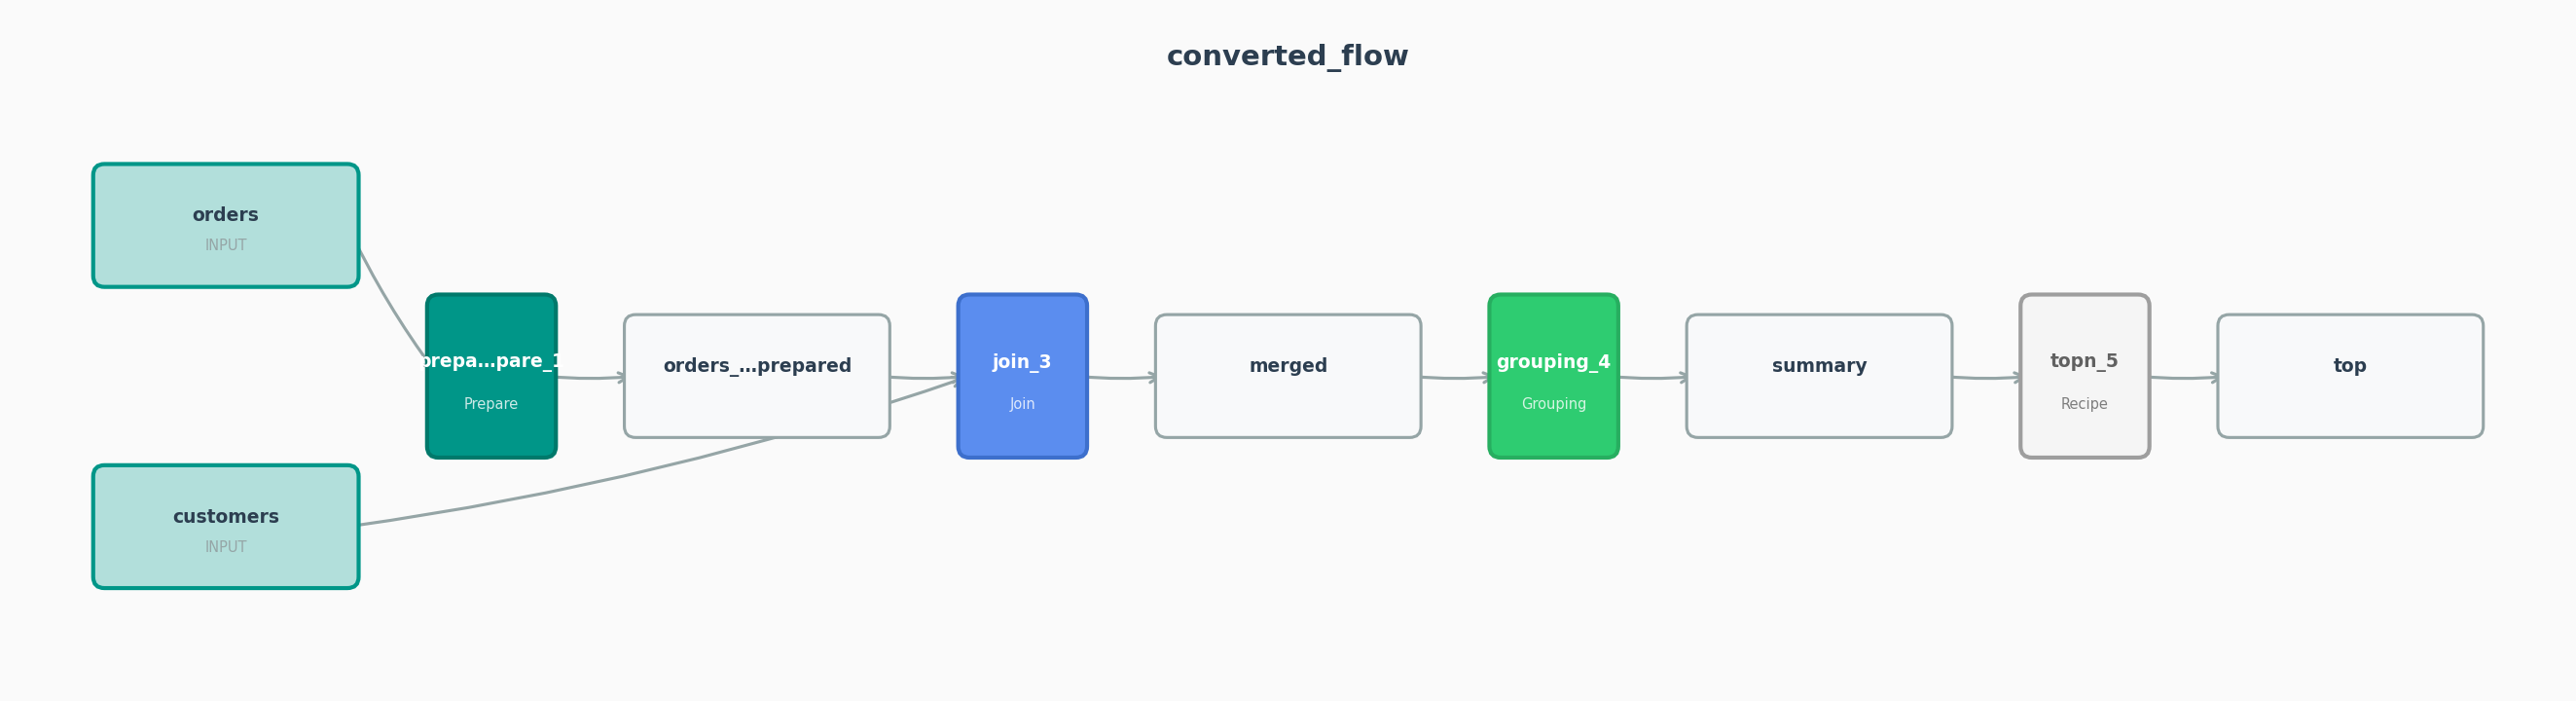

In [3]:
# PNG export - publication-quality diagram
from py2dataiku.visualizers import MatplotlibVisualizer
from IPython.display import Image, display

viz = MatplotlibVisualizer()
png_bytes = viz.render(demo_flow)
display(Image(png_bytes))

---
## 1. Importing the Library

The main entry points are the `convert()` and `convert_file()` functions, plus the
core model classes `DataikuFlow`, `DataikuRecipe`, and `DataikuDataset`.

In [4]:
from py2dataiku import convert, convert_file, DataikuFlow
from py2dataiku import DataikuRecipe, RecipeType
from py2dataiku import DataikuDataset, DatasetType

print("py-iku imported successfully")

py-iku imported successfully


---
## 2. Your First Conversion

The `convert()` function takes a Python code string and returns a `DataikuFlow`.
It uses rule-based AST pattern matching to identify pandas operations and map
them to Dataiku recipe types.

In [5]:
# A simple pandas pipeline: read CSV and drop missing values
code = """
import pandas as pd
df = pd.read_csv('sales.csv')
df = df.dropna()
"""

flow = convert(code)
print(type(flow))  # DataikuFlow
print(flow)

<class 'py2dataiku.models.dataiku_flow.DataikuFlow'>
DataikuFlow(name='converted_flow', datasets=2, recipes=1)


The `convert()` function returns a `DataikuFlow` object, which is the main output
of py-iku. It contains datasets (data nodes) and recipes (transformation nodes)
that form a directed acyclic graph (DAG).

---
## 3. Understanding DataikuFlow

A `DataikuFlow` has two main collections:
- **datasets**: the data containers (input, intermediate, output)
- **recipes**: the transformation steps between datasets

In [6]:
# Inspect the flow's name and timestamp
print(f"Flow name: {flow.name}")
print(f"Generated: {flow.generation_timestamp}")
print(f"Number of datasets: {len(flow.datasets)}")
print(f"Number of recipes: {len(flow.recipes)}")

Flow name: converted_flow
Generated: 2026-04-25T10:34:10.578470
Number of datasets: 2
Number of recipes: 1


In [7]:
# List all datasets
for ds in flow.datasets:
    print(f"  {ds.name} (type={ds.dataset_type.value})")

  df (type=input)
  df_prepared (type=intermediate)


In [8]:
# Datasets are categorized: input, intermediate, output
print("Input datasets:", [ds.name for ds in flow.input_datasets])
print("Intermediate datasets:", [ds.name for ds in flow.intermediate_datasets])
print("Output datasets:", [ds.name for ds in flow.output_datasets])

Input datasets: ['df']
Intermediate datasets: ['df_prepared']
Output datasets: []


---
## 4. Understanding DataikuRecipe

Recipes are the transformation nodes in the flow. Each recipe has:
- A `name` and a `recipe_type` (from the `RecipeType` enum)
- `inputs` and `outputs` (lists of dataset names)
- Type-specific attributes (e.g., `steps` for PREPARE recipes)

In [9]:
# List all recipes in the flow
for recipe in flow.recipes:
    print(f"Recipe: {recipe.name}")
    print(f"  Type: {recipe.recipe_type.value}")
    print(f"  Inputs: {recipe.inputs}")
    print(f"  Outputs: {recipe.outputs}")
    print()

Recipe: prepare_1
  Type: prepare
  Inputs: ['df']
  Outputs: ['df_prepared']



---
## 5. Understanding DataikuDataset

Each dataset has:
- A `name`
- A `dataset_type` (`INPUT`, `INTERMEDIATE`, or `OUTPUT`)
- A `connection_type` (default: `FILESYSTEM`)
- Optional `schema`, `source_variable`, and `source_line`

In [10]:
# Inspect the first dataset in detail
if flow.datasets:
    ds = flow.datasets[0]
    print(f"Name: {ds.name}")
    print(f"Dataset type: {ds.dataset_type}")
    print(f"Connection type: {ds.connection_type}")
    print(f"Is input: {ds.is_input}")
    print(f"Is output: {ds.is_output}")

Name: df
Dataset type: DatasetType.INPUT
Connection type: DatasetConnectionType.FILESYSTEM
Is input: True
Is output: False


In [11]:
# Look up a dataset by name
found = flow.get_dataset(flow.datasets[0].name)
print(f"Found dataset: {found}")

Found dataset: DataikuDataset(name='df', type=input)


---
## 6. Iterating Over a Flow

`DataikuFlow` supports Python's iteration protocol:
- `len(flow)` returns the number of recipes
- `for recipe in flow` iterates over recipes

In [12]:
# len() returns the recipe count
print(f"Number of recipes: {len(flow)}")

Number of recipes: 1


In [13]:
# Iterate over recipes using a for loop
for i, recipe in enumerate(flow):
    print(f"Recipe {i}: {recipe.name} ({recipe.recipe_type.value})")

Recipe 0: prepare_1 (prepare)


---
## 7. Flow Summary

The `get_summary()` method provides a text overview of the entire flow,
including dataset counts, recipe counts by type, and optimization notes.

In [14]:
print(flow.get_summary())

Flow: converted_flow
Source: unknown
Generated: 2026-04-25T10:34:10.578470

Datasets: 2
  - Input: 1
  - Intermediate: 1
  - Output: 0

Recipes: 1
  - prepare: 1

Optimization Notes:
  - prepare: 1 recipe(s)


---
## 8. Visualization

py-iku can visualize flows in multiple formats. The `flow.visualize()` method
accepts a `format` parameter. Here we demonstrate **ASCII**, **SVG**, and **Mermaid**.

### 8.1 ASCII Visualization

Great for quick terminal-friendly output.

In [15]:
ascii_output = flow.visualize(format="ascii")
print(ascii_output)

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 df             │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 1 steps      │
                                └──────────────┘

                                       │
                                       ▼

                              ┌──────────────────┐
                              │ 📊 df_prepared    │
                              └──────────────────┘

═════════

### 8.2 SVG Visualization (Jupyter Inline)

When a `DataikuFlow` is the last expression in a Jupyter cell, it renders inline
via `_repr_svg_()`. You can also use `flow.visualize(format="svg")` explicitly.

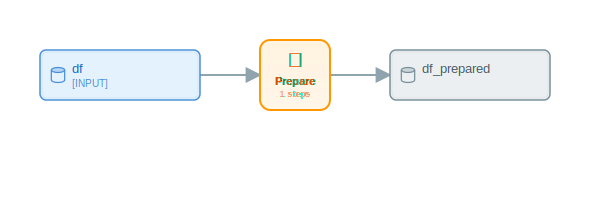

In [16]:
# SVG renders inline in Jupyter via _repr_svg_()
# Simply evaluate the flow as the last expression in a cell:
flow

### 8.3 Mermaid Visualization

Mermaid diagrams can be rendered in GitHub, Notion, and many Markdown viewers.

In [17]:
mermaid_output = flow.visualize(format="mermaid")
print(mermaid_output)

flowchart TD
    subgraph inputs[Input Datasets]
        D0[(df)]
    end
    D1[(df_prepared)]
    R0{Prepare\n(1 steps)}
    D0 --> R0
    R0 --> D1

    style D0 fill:#e1f5fe
    style R0 fill:#fff3e0


### 8.3 PlantUML Visualization

PlantUML diagrams for technical documentation and UML tools.

In [18]:
plantuml_output = flow.visualize(format='plantuml')
print(plantuml_output)

@startuml
!theme plain
skinparam backgroundColor #FAFAFA
skinparam defaultFontName Arial
skinparam defaultFontSize 12

' Dataset styles
skinparam rectangle {
  BackgroundColor<<input>> #E3F2FD
  BorderColor<<input>> #4A90D9
  FontColor<<input>> #1565C0
  BackgroundColor<<output>> #E8F5E9
  BorderColor<<output>> #43A047
  FontColor<<output>> #2E7D32
  BackgroundColor<<intermediate>> #ECEFF1
  BorderColor<<intermediate>> #78909C
  FontColor<<intermediate>> #455A64
}

' Recipe styles
skinparam card {
  BackgroundColor<<prepare>> #FFF3E0
  BorderColor<<prepare>> #FF9800
  BackgroundColor<<join>> #E3F2FD
  BorderColor<<join>> #2196F3
  BackgroundColor<<grouping>> #E8F5E9
  BorderColor<<grouping>> #4CAF50
  BackgroundColor<<split>> #FCE4EC
  BorderColor<<split>> #E91E63
  BackgroundColor<<python>> #E8EAF6
  BorderColor<<python>> #3F51B5
}

' Arrow style
skinparam arrow {
  Color #90A4AE
  Thickness 2
}

' Datasets
rectangle "df" <<input>> as df
rectangle "df_prepared" <<intermediate>> as df_

---
## 9. Serialization Round-Trips

Flows can be serialized to dictionaries, JSON, or YAML, and reconstructed
back. This is useful for saving, sharing, and versioning flow definitions.

### 9.1 to_dict / from_dict

In [19]:
# Serialize to a dictionary
flow_dict = flow.to_dict()
print(f"Dict keys: {list(flow_dict.keys())}")
print(f"Flow name from dict: {flow_dict['flow_name']}")
print(f"Total recipes: {flow_dict['total_recipes']}")
print(f"Total datasets: {flow_dict['total_datasets']}")

Dict keys: ['flow_name', 'generated_from', 'generation_timestamp', 'total_recipes', 'total_datasets', 'datasets', 'recipes', 'optimization_notes', 'recommendations']
Flow name from dict: converted_flow
Total recipes: 1
Total datasets: 2


In [20]:
# Reconstruct from dictionary
flow_restored = DataikuFlow.from_dict(flow_dict)
print(f"Restored flow: {flow_restored}")
print(f"Recipes match: {len(flow_restored) == len(flow)}")

Restored flow: DataikuFlow(name='converted_flow', datasets=2, recipes=1)
Recipes match: True


### 9.2 to_json / from_json

In [21]:
# Serialize to JSON string
json_str = flow.to_json(indent=2)
print(json_str[:300])  # Print the first 300 chars
print("...")

{
  "flow_name": "converted_flow",
  "generated_from": null,
  "generation_timestamp": "2026-04-25T10:34:10.578470",
  "total_recipes": 1,
  "total_datasets": 2,
  "datasets": [
    {
      "name": "df",
      "type": "input",
      "connection_type": "Filesystem",
      "schema": [],
      "source_
...


In [22]:
# Reconstruct from JSON string
flow_from_json = DataikuFlow.from_json(json_str)
print(f"From JSON: {flow_from_json}")
print(f"Names match: {flow_from_json.name == flow.name}")

From JSON: DataikuFlow(name='converted_flow', datasets=2, recipes=1)
Names match: True


### 9.3 Auto-detect format with `flow.save()` / `DataikuFlow.load()` (recommended)

The lower-level `to_json` / `to_yaml` methods return strings — you write the file yourself. The higher-level `flow.save(path)` infers the format from the extension and writes the file for you. `DataikuFlow.load(path)` is the symmetric counterpart. Same auto-detection works for `.svg`, `.html`, `.png`, `.pdf`, `.puml`, `.txt`, `.md`.

In [23]:
import tempfile
from pathlib import Path

with tempfile.TemporaryDirectory() as tmpdir:
    json_path = Path(tmpdir) / 'flow.json'
    yaml_path = Path(tmpdir) / 'flow.yaml'
    
    # Save: extension auto-detects format
    flow.save(str(json_path))
    flow.save(str(yaml_path))
    
    # Load: symmetric — also auto-detects format from extension
    reloaded = DataikuFlow.load(str(json_path))
    
    print(f'JSON: {json_path.stat().st_size} bytes')
    print(f'YAML: {yaml_path.stat().st_size} bytes')
    print(f'Reloaded recipes: {len(reloaded.recipes)} '
          f'(matches original: {len(reloaded.recipes) == len(flow.recipes)})')


JSON: 1139 bytes
YAML: 732 bytes
Reloaded recipes: 1 (matches original: True)


---
## 10. Converting from a File

The `convert_file()` function reads a `.py` file and converts it.
Let's write a temporary Python file and convert it.

In [24]:
import tempfile
import os

# Write a temporary Python file
pipeline_code = """
import pandas as pd

df = pd.read_csv('customers.csv')
df = df.dropna()
df = df.sort_values('signup_date')
df.to_csv('customers_clean.csv', index=False)
"""

tmp_file = os.path.join(tempfile.gettempdir(), "my_pipeline.py")
with open(tmp_file, "w") as f:
    f.write(pipeline_code)

print(f"Written to: {tmp_file}")

Written to: /var/folders/_6/yhy5krgn18d9n4fzp832dpr00000gn/T/my_pipeline.py


In [25]:
# Convert from file
file_flow = convert_file(tmp_file)

print(f"Source file: {file_flow.source_file}")
print()
print(file_flow.get_summary())

Source file: /var/folders/_6/yhy5krgn18d9n4fzp832dpr00000gn/T/my_pipeline.py

Flow: converted_flow
Source: /var/folders/_6/yhy5krgn18d9n4fzp832dpr00000gn/T/my_pipeline.py
Generated: 2026-04-25T10:34:11.406131

Datasets: 3
  - Input: 1
  - Intermediate: 1
  - Output: 1

Recipes: 2
  - prepare: 1
  - sort: 1

Optimization Notes:
  - prepare: 1 recipe(s)
  - sort: 1 recipe(s)


### 10.1 Path polymorphism (`convert()` accepts `pathlib.Path` directly)

`convert()` and `convert_with_llm()` accept three input forms — an inline source string, a `pathlib.Path` to a `.py` file, or a string path ending in `.py`. The function detects which you passed and reads the file when needed.

In [26]:
from pathlib import Path

# All three forms produce the same flow:
flow_via_path = convert(Path(tmp_file))      # pathlib.Path
flow_via_str_path = convert(tmp_file)         # string path
flow_via_helper = convert_file(tmp_file)      # explicit helper

print(f'Path form:        {len(flow_via_path.recipes)} recipes')
print(f'String-path form: {len(flow_via_str_path.recipes)} recipes')
print(f'convert_file:     {len(flow_via_helper.recipes)} recipes')


Path form:        2 recipes
String-path form: 2 recipes
convert_file:     2 recipes


In [27]:
# Clean up the temporary file
os.remove(tmp_file)

---
## 11. Practical Examples

Below are several simple pandas patterns and their Dataiku flow equivalents.

### Example 1: Read CSV

`pd.read_csv()` creates an input dataset in the flow.

In [28]:
flow_read = convert("""
import pandas as pd
df = pd.read_csv('orders.csv')
""")

print(f"Datasets: {[ds.name for ds in flow_read.datasets]}")
print(f"Recipes: {len(flow_read)}")
print(flow_read.visualize(format="ascii"))

Datasets: ['df']
Recipes: 0
════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 df             │
                             │    [INPUT]        │
                              └──────────────────┘

════════════════════════════════════════════════════════════════════════════════

Legend: 📊 Dataset  ⚙ Prepare  ⋈ Join  Σ Grouping  ⑂ Split  ⇅ Sort


### Example 2: Drop Missing Values (dropna)

`df.dropna()` maps to a PREPARE recipe with a REMOVE_ROWS_ON_EMPTY processor.

In [29]:
flow_dropna = convert("""
import pandas as pd
df = pd.read_csv('data.csv')
df = df.dropna()
""")

for recipe in flow_dropna:
    print(f"Recipe: {recipe.name} (type={recipe.recipe_type.value})")
    if recipe.steps:
        for step in recipe.steps:
            print(f"  Step: {step.processor_type.value}")

print()
print(flow_dropna.visualize(format="ascii"))

Recipe: prepare_1 (type=prepare)
  Step: RemoveRowsOnEmpty

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 df             │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 1 steps      │
                                └──────────────┘

                                       │
                                       ▼

                              ┌──────────────────┐
                              │ 📊 df_prepared    │
 

### Example 3: Sort Values

`df.sort_values()` maps to a SORT recipe.

In [30]:
flow_sort = convert("""
import pandas as pd
df = pd.read_csv('products.csv')
df = df.sort_values('price', ascending=False)
""")

for recipe in flow_sort:
    print(f"Recipe: {recipe.name} (type={recipe.recipe_type.value})")

print()
print(flow_sort.visualize(format="ascii"))

Recipe: sort_1 (type=sort)

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 df             │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⇅ SORT      │
                                │ ──────────── │
                                └──────────────┘

                                       │
                                       ▼

                              ┌──────────────────┐
                              │ 📊 df_sorted      │
                              └──────────────────┘

══════════════════════════════

### Example 4: Group By with Aggregation

`df.groupby().agg()` maps to a GROUPING recipe.

In [31]:
flow_group = convert("""
import pandas as pd
df = pd.read_csv('sales.csv')
result = df.groupby('region').agg({'revenue': 'sum'})
""")

for recipe in flow_group:
    print(f"Recipe: {recipe.name} (type={recipe.recipe_type.value})")
    if recipe.recipe_type == RecipeType.GROUPING:
        print(f"  Group keys: {recipe.group_keys}")
        for agg in recipe.aggregations:
            print(f"  Aggregation: {agg.function}({agg.column})")

print()
print(flow_group.visualize(format="ascii"))

Recipe: grouping_1 (type=grouping)
  Group keys: ['region']
  Aggregation: SUM(revenue)

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 df             │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   Σ GROUPING  │
                                │ ──────────── │
                                │ 1 aggs       │
                                └──────────────┘

                                       │
                                       ▼

                              ┌──────────────────┐
                       

### Example 5: Drop Duplicates

`df.drop_duplicates()` maps to a PREPARE recipe with deduplication processing.

In [32]:
flow_distinct = convert("""
import pandas as pd
df = pd.read_csv('emails.csv')
df = df.drop_duplicates()
""")

for recipe in flow_distinct:
    print(f"Recipe: {recipe.name} (type={recipe.recipe_type.value})")

print()
print(flow_distinct.visualize(format="ascii"))

Recipe: prepare_1 (type=prepare)



════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 df             │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 1 steps      │
                                └──────────────┘

                                       │
                                       ▼

                              ┌──────────────────┐
                              │ 📊 df_prepared    │
                              └──────────────────┘

═══════

### Example 6: Rename Columns

`df.rename(columns=...)` maps to a PREPARE recipe with a COLUMN_RENAMER processor.

In [33]:
flow_rename = convert("""
import pandas as pd
df = pd.read_csv('users.csv')
df = df.rename(columns={'old_name': 'new_name'})
""")

for recipe in flow_rename:
    print(f"Recipe: {recipe.name} (type={recipe.recipe_type.value})")
    if recipe.steps:
        for step in recipe.steps:
            print(f"  Step: {step.processor_type.value} - params: {step.params}")

print()
print(flow_rename.visualize(format="ascii"))

Recipe: prepare_1 (type=prepare)
  Step: ColumnRenamer - params: {'renamings': [{'from': 'old_name', 'to': 'new_name'}]}

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 df             │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 1 steps      │
                                └──────────────┘

                                       │
                                       ▼

                              ┌──────────

---
## 12. Combining Multiple Operations

Real pipelines chain multiple operations. py-iku handles multi-step
code and produces a flow with multiple recipes.

In [34]:
multi_step_code = """
import pandas as pd

# Load data
df = pd.read_csv('transactions.csv')

# Clean: remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Sort by date
df = df.sort_values('transaction_date')

# Aggregate by category
summary = df.groupby('category').agg({'amount': 'sum'})
"""

flow_multi = convert(multi_step_code)
print(flow_multi.get_summary())

Flow: converted_flow
Source: unknown
Generated: 2026-04-25T10:34:11.906892

Datasets: 4
  - Input: 1
  - Intermediate: 3
  - Output: 0

Recipes: 3
  - grouping: 1
  - prepare: 1
  - sort: 1

Optimization Notes:
  - prepare: 1 recipe(s)
  - sort: 1 recipe(s)
  - grouping: 1 recipe(s)


In [35]:
# Visualize the multi-step flow in ASCII
print(flow_multi.visualize(format="ascii"))

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 df             │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 2 steps      │
                                └──────────────┘

                                       │
                                       ▼

                              ┌──────────────────┐
                              │ 📊 df_prepared    │
                              └──────────────────┘

         

In [36]:
# Visualize the multi-step flow in Mermaid
print(flow_multi.visualize(format="mermaid"))

flowchart TD
    subgraph inputs[Input Datasets]
        D0[(df)]
    end
    D1[(df_prepared)]
    D2[(df_prepared_sorted)]
    D3[(summary)]
    R0{Prepare\n(2 steps)}
    R1{Sort}
    R2{Grouping\n(1 aggs)}
    D0 --> R0
    R0 --> D1
    D1 --> R1
    R1 --> D2
    D2 --> R2
    R2 --> D3

    style D0 fill:#e1f5fe
    style R0 fill:#fff3e0
    style R1 fill:#f5f5f5
    style R2 fill:#e8f5e9


---
## 13. Inspecting Recipe Details

You can look up recipes by name or by type, and inspect their
internal configuration.

In [37]:
# Look up a recipe by name
if flow_multi.recipes:
    first_recipe = flow_multi.recipes[0]
    found_recipe = flow_multi.get_recipe(first_recipe.name)
    print(f"Found recipe by name: {found_recipe}")

Found recipe by name: DataikuRecipe(name='prepare_1', type=prepare)


In [38]:
# Find recipes by type
grouping_recipes = flow_multi.get_recipes_by_type(RecipeType.GROUPING)
print(f"Grouping recipes: {len(grouping_recipes)}")
for r in grouping_recipes:
    print(f"  {r.name}: keys={r.group_keys}")

Grouping recipes: 1
  grouping_3: keys=['category']


---
## 14. Converting Recipes to Dictionaries

Individual recipes can also be serialized for inspection or export.

In [39]:
import json

# Serialize a single recipe to a dictionary
if flow_multi.recipes:
    recipe_dict = flow_multi.recipes[0].to_dict()
    print(json.dumps(recipe_dict, indent=2))

{
  "name": "prepare_1",
  "type": "prepare",
  "inputs": [
    "df"
  ],
  "outputs": [
    "df_prepared"
  ],
  "source_lines": [],
  "notes": [],
  "steps": [
    {
      "metaType": "PROCESSOR",
      "type": "RemoveRowsOnEmpty",
      "disabled": false,
      "params": {
        "columns": null,
        "keep": false
      }
    },
    {
      "metaType": "PROCESSOR",
      "type": "RemoveDuplicates",
      "disabled": false,
      "params": {}
    }
  ],
  "step_count": 2
}


---
## 15. HTML Visualization

The HTML format produces a canvas-based interactive visualization.

In [40]:
from IPython.display import HTML

# HTML visualization produces an interactive canvas
html_output = demo_flow.visualize(format="html")
print(f"HTML output: {len(html_output)} characters")
print(f"Preview: {html_output[:150]}...")

HTML output: 14485 characters
Preview: <!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <tit...


---
## 16. Format Comparison

py-iku supports 6 visualization formats. Here we show the same flow in multiple formats side by side.

In [41]:
# Compare all text-based formats for the demo_flow
for fmt in ["ascii", "mermaid", "plantuml"]:
    output = demo_flow.visualize(format=fmt)
    print(f"=== {fmt.upper()} ===")
    print(output)
    print()

=== ASCII ===
════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 orders         │
                             │    [INPUT]        │
                              └──────────────────┘

                              ┌──────────────────┐
                              │ 📊 customers      │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 2 steps      │
                                └──────────────┘

                           

---
## 17. Flow Graph Basics (DAG)

Every `DataikuFlow` has a `graph` property that returns a `FlowGraph` -- a directed acyclic graph
representing the flow's structure. This enables topological sorting, root/leaf discovery, and more.

In [42]:
# Access the DAG through the graph property
dag = demo_flow.graph
print(f"Flow graph: {dag}")
print(f"Root nodes (data sources): {dag.get_roots()}")
print(f"Leaf nodes (final outputs): {dag.get_leaves()}")
print()

# Topological sort gives the execution order
print("Execution order (topological sort):")
for i, name in enumerate(dag.topological_sort(), 1):
    node = dag.get_node(name)
    print(f"  {i}. [{node.node_type.value}] {name}")

print(f"\nCycles detected: {dag.detect_cycles()}")
print(f"Connected components: {len(dag.find_disconnected_subgraphs())}")

Flow graph: FlowGraph(nodes=10, edges=9)
Root nodes (data sources): ['orders', 'customers']
Leaf nodes (final outputs): ['top']

Execution order (topological sort):
  1. [dataset] orders
  2. [dataset] customers
  3. [recipe] recipe:prepare_merged_prepare_1
  4. [dataset] orders_prepared_prepared
  5. [recipe] recipe:join_3
  6. [dataset] merged
  7. [recipe] recipe:grouping_4
  8. [dataset] summary
  9. [recipe] recipe:topn_5
  10. [dataset] top

Cycles detected: []
Connected components: 1


---
## 18. Column Lineage

The `get_column_lineage()` method traces a column backward through the flow's recipes
to find its origin dataset and any transformations applied.

In [43]:
# Trace the 'amount' column through the demo_flow
lineage = demo_flow.get_column_lineage("amount")
print(f"Column: {lineage.column}")
print(f"Origin dataset: {lineage.origin_dataset}")
print(f"Origin column: {lineage.origin_column}")
print(f"Final dataset: {lineage.final_dataset}")
print(f"Transformations: {lineage.transformations}")

Column: amount
Origin dataset: orders
Origin column: amount
Final dataset: top
Transformations: [{'type': 'join', 'recipe': 'join_3', 'join_type': 'INNER'}, {'type': 'aggregation', 'recipe': 'grouping_4', 'function': 'SUM', 'source_column': 'amount'}]


---
## Summary

In this notebook you learned:

- **`convert(code)`** analyzes a Python code string using rule-based AST matching and returns a `DataikuFlow`.
- **`DataikuFlow`** holds `datasets` and `recipes`, supports `len()`, iteration, and `get_summary()`.
- **`DataikuRecipe`** represents a transformation node with a `recipe_type`, `inputs`, `outputs`, and type-specific fields.
- **`DataikuDataset`** represents a data node with a `dataset_type` (INPUT, INTERMEDIATE, OUTPUT).
- **Visualization**: `flow.visualize(format="ascii")` for terminal output, `flow.visualize(format="mermaid")` for Markdown-compatible diagrams.
- **Serialization**: `to_dict()`/`from_dict()` and `to_json()`/`from_json()` enable round-trip persistence.
- **`convert_file(path)`** reads a `.py` file and converts it, setting `flow.source_file`.

**Common pandas-to-Dataiku mappings covered:**

| pandas operation | Dataiku recipe type |
|---|---|
| `pd.read_csv()` | Input dataset |
| `df.dropna()` | PREPARE (REMOVE_ROWS_ON_EMPTY) |
| `df.sort_values()` | SORT |
| `df.groupby().agg()` | GROUPING |
| `df.drop_duplicates()` | PREPARE (deduplication) |
| `df.rename(columns=...)` | PREPARE (COLUMN_RENAMER) |

Next notebook: **02_intermediate.ipynb** covers more recipe types, join operations, and advanced visualization formats.

---
## 15. Deploying to Dataiku DSS

py-iku can deploy flows directly to a Dataiku DSS instance using `DSSFlowDeployer`.
In **dry-run mode**, the deployer validates the flow and shows what *would* be created
without making any API calls -- no DSS connection or `dataikuapi` package required.

In [44]:
from py2dataiku.integrations import DSSFlowDeployer

# Create a deployer in dry-run mode (no DSS connection required)
deployer = DSSFlowDeployer(
    host="https://dss.example.com",
    api_key="dummy-api-key",
    project_key="BEGINNER_DEMO",
    dry_run=True,
)

# Deploy the demo_flow we created at the top of this notebook
result = deployer.deploy(demo_flow)
print(result)
print(f"\nSuccess: {result.success}")
print(f"Datasets that would be created: {result.datasets_created}")
print(f"Recipes that would be created: {result.recipes_created}")

DeploymentResult(DRY RUN: 6 datasets, 4 recipes, 0 errors)

Success: True
Datasets that would be created: ['orders', 'customers', 'orders_prepared_prepared', 'merged', 'summary', 'top']
Recipes that would be created: ['prepare_merged_prepare_1', 'join_3', 'grouping_4', 'topn_5']


In [45]:
# Inspect the deployment result in detail
print("Deployment Result Details:")
print(f"  Dry run: {result.dry_run}")
print(f"  Warnings: {result.warnings}")
print(f"  Errors: {result.errors}")
print()

# The result can also be serialized to a dictionary
result_dict = result.to_dict()
print("Result as dict:")
for key, value in result_dict.items():
    print(f"  {key}: {value}")

Deployment Result Details:
  Dry run: True
  Warnings: []
  Errors: []

Result as dict:
  datasets_created: ['orders', 'customers', 'orders_prepared_prepared', 'merged', 'summary', 'top']
  recipes_created: ['prepare_merged_prepare_1', 'join_3', 'grouping_4', 'topn_5']
  errors: []
  warnings: []
  dry_run: True
  success: True


**What is dry-run mode?**

When `dry_run=True`, the deployer:
- Validates the flow structure (checks for cycles, missing connections)
- Determines the topological order for creating datasets and recipes
- Returns a `DeploymentResult` listing what *would* be created
- Does **not** make any network calls or require `dataikuapi` to be installed

This is useful for previewing a deployment before connecting to a live DSS instance.
To deploy for real, set `dry_run=False` and provide a valid DSS `host` and `api_key`.